# 04 - Exploración del dataset para detección de platos

## Objetivo del notebook

Este notebook inicia el módulo central de Hidden Gems: la detección de menciones de platos en reseñas gastronómicas.

El objetivo no es entrenar todavía el modelo final, sino construir una base sólida para ello:

- cargar el corpus Yelp gastronómico;
- analizar textos ricos en menciones de comida;
- construir un diccionario inicial de platos en inglés;
- detectar menciones candidatas mediante reglas y patrones;
- identificar falsos positivos frecuentes;
- generar un primer dataset de candidatos;
- preparar la futura anotación manual y el posterior entrenamiento NER.

## Por qué este paso es necesario

El corpus Yelp tiene sentimiento derivado de ratings, pero no contiene anotaciones de platos a nivel de texto.

Por tanto, antes de entrenar un modelo NER necesitamos crear una primera capa de detección débil (*weak labeling*) y analizar qué tipos de menciones aparecen realmente en las reviews.

In [1]:
# ============================================================
# 01. Imports y configuración base
# ============================================================

from pathlib import Path
import json
import random
import re
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 300)

print("Entorno inicializado correctamente.")

Entorno inicializado correctamente.


In [2]:
# ============================================================
# 02. Detectar entorno de ejecución
# ============================================================

import os

IS_KAGGLE = Path("/kaggle/input").exists()
IS_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IS_KAGGLE:
    ENV_NAME = "kaggle"
elif IS_COLAB:
    ENV_NAME = "colab"
else:
    ENV_NAME = "local"

print("Entorno detectado:", ENV_NAME)

if IS_KAGGLE:
    INPUT_DIR = Path("/kaggle/input")
    WORKING_DIR = Path("/kaggle/working")
    PROJECT_DIR = WORKING_DIR / "hidden_gems_ai"
    DATA_DIR = PROJECT_DIR / "data"

elif IS_COLAB:
    from google.colab import drive

    try:
        !fusermount -u /content/drive 2>/dev/null || true
        !rm -rf /content/drive

        drive.mount("/content/drive", force_remount=True, timeout_ms=120000)

        PROJECT_DIR = Path("/content/drive/MyDrive/hidden_gems_ai")
        DATA_DIR = PROJECT_DIR / "data"

    except Exception as e:
        print("No se ha podido montar Drive. Se usará almacenamiento temporal.")
        print("Error:", e)

        PROJECT_DIR = Path("/content/hidden_gems_ai")
        DATA_DIR = PROJECT_DIR / "data"

else:
    PROJECT_DIR = Path.cwd()
    DATA_DIR = PROJECT_DIR / "data"

OUTPUT_DIR = PROJECT_DIR / "outputs" / "dish_detection_exploration"
ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"
CANDIDATES_DIR = OUTPUT_DIR / "candidates"
SAMPLES_DIR = OUTPUT_DIR / "samples"

for path in [PROJECT_DIR, DATA_DIR, OUTPUT_DIR, ARTIFACTS_DIR, CANDIDATES_DIR, SAMPLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

Entorno detectado: kaggle
PROJECT_DIR: /kaggle/working/hidden_gems_ai
DATA_DIR: /kaggle/working/hidden_gems_ai/data
OUTPUT_DIR: /kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration


In [3]:
# ============================================================
# 03. Localizar corpus Yelp
# ============================================================

EXPECTED_FILENAME = "yelp_food_reviews_corpus_sample_100k_lines.jsonl"

candidate_paths = []

# 1. Buscar en Kaggle input
if IS_KAGGLE:
    candidate_paths.extend(list(Path("/kaggle/input").rglob(EXPECTED_FILENAME)))

# 2. Buscar en DATA_DIR
candidate_paths.extend(list(DATA_DIR.rglob(EXPECTED_FILENAME)))

# 3. Buscar en PROJECT_DIR
candidate_paths.extend(list(PROJECT_DIR.rglob(EXPECTED_FILENAME)))

candidate_paths = list(dict.fromkeys(candidate_paths))

print("Rutas candidatas encontradas:")
for path in candidate_paths:
    print("-", path)

if not candidate_paths:
    raise FileNotFoundError(
        f"No se ha encontrado {EXPECTED_FILENAME}.\n"
        "En Kaggle, añade el dataset desde Add Data.\n"
        "En Colab/local, coloca el archivo dentro de DATA_DIR."
    )

CORPUS_PATH = candidate_paths[0]

print("\nCorpus seleccionado:")
print(CORPUS_PATH)

Rutas candidatas encontradas:
- /kaggle/input/datasets/ivanarteagacordero/hidden-gems-yelp-nlp/yelp_food_reviews_corpus_sample_100k_lines.jsonl

Corpus seleccionado:
/kaggle/input/datasets/ivanarteagacordero/hidden-gems-yelp-nlp/yelp_food_reviews_corpus_sample_100k_lines.jsonl


In [4]:
# ============================================================
# 04. Cargar corpus JSONL
# ============================================================

def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    invalid_json_count = 0

    with path.open("r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Leyendo corpus"):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                invalid_json_count += 1

    print(f"Registros cargados: {len(records):,}")
    print(f"Líneas JSON inválidas: {invalid_json_count:,}")

    return pd.DataFrame(records)


df_raw = load_jsonl(CORPUS_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head(3))

Leyendo corpus: 0it [00:00, ?it/s]

Registros cargados: 79,270
Líneas JSON inválidas: 0
Shape: (79270, 20)


,corpus_document_id,source_system_code,source_dataset,source_entity_type,source_review_id,source_business_id,source_user_id,text,text_normalized,language,rating_value,sentiment_label_from_rating,review_date,corpus_split,task_scope,is_training_eligible,quality_flags,business_metadata,source_metrics,created_at
0,yelp_2fbfd094613536a7b8c9231b,yelp_open_dataset,yelp_open_dataset,yelp_review,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,mh_-eMZ6K5RLWhZyISBhwA,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The...","If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The...",en,3.0,neutral,2018-07-07 22:09:11,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 511, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Turning Point of North Wales', 'city': 'North Wales', 'state': 'PA', 'stars_business': 3.0, 'review_count_business': 169, 'is_open': 1, 'categories_list': ['Restaurants', 'Breakfast & Brunch', 'Food', 'Juice Bars & Smoothies', 'American (New)', 'Coffee & Tea', 'Sandwiches'], '...","{'useful_count': 0, 'funny_count': 0, 'cool_count': 0}",2026-05-06T10:57:56.623430+00:00
1,yelp_94c5a64cecd4448d105e5c8a,yelp_open_dataset,yelp_open_dataset,yelp_review,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,8g_iMtfSiwikVnbP2etR0A,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ...","Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ...",en,3.0,neutral,2014-02-05 20:30:30,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 339, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Kettle Restaurant', 'city': 'Tucson', 'state': 'AZ', 'stars_business': 3.5, 'review_count_business': 47, 'is_open': 1, 'categories_list': ['Restaurants', 'Breakfast & Brunch'], 'food_category_tags': ['Breakfast & Brunch', 'Restaurants'], 'food_confidence': 0.95}","{'useful_count': 0, 'funny_count': 0, 'cool_count': 0}",2026-05-06T10:57:56.624430+00:00
2,yelp_69e10d25d69774ab39af6571,yelp_open_dataset,yelp_open_dataset,yelp_review,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,_7bHUi9Uuf5__HHc_Q8guQ,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!","Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",en,5.0,positive,2015-01-04 00:01:03,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 235, 'label_is_weak': Tru

In [5]:
# ============================================================
# 05. Validación inicial de columnas
# ============================================================

required_cols = [
    "corpus_document_id",
    "source_review_id",
    "source_business_id",
    "text",
    "text_normalized",
    "language",
    "rating_value",
    "sentiment_label_from_rating",
    "corpus_split",
]

missing_cols = [col for col in required_cols if col not in df_raw.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas obligatorias: {missing_cols}")

print("Columnas obligatorias presentes.")

print("\nColumnas disponibles:")
for col in df_raw.columns:
    print("-", col)

print("\nNulos en columnas obligatorias:")
display(df_raw[required_cols].isna().sum())

print("\nDistribución de idioma:")
display(df_raw["language"].value_counts())

print("\nDistribución de split:")
display(df_raw["corpus_split"].value_counts())

print("\nDistribución de sentimiento:")
display(df_raw["sentiment_label_from_rating"].value_counts())

Columnas obligatorias presentes.

Columnas disponibles:
- corpus_document_id
- source_system_code
- source_dataset
- source_entity_type
- source_review_id
- source_business_id
- source_user_id
- text
- text_normalized
- language
- rating_value
- sentiment_label_from_rating
- review_date
- corpus_split
- task_scope
- is_training_eligible
- quality_flags
- business_metadata
- source_metrics
- created_at

Nulos en columnas obligatorias:


corpus_document_id             0
source_review_id               0
source_business_id             0
text                           0
text_normalized                0
language                       0
rating_value                   0
sentiment_label_from_rating    0
corpus_split                   0
dtype: int64


Distribución de idioma:


language
en    79270
Name: count, dtype: int64


Distribución de split:


corpus_split
train         63540
test           7881
validation     7849
Name: count, dtype: int64


Distribución de sentimiento:


sentiment_label_from_rating
positive    54857
negative    14578
neutral      9835
Name: count, dtype: int64

In [6]:
# ============================================================
# 06. Preparar dataframe base
# ============================================================

df = df_raw.copy()

df["review_id"] = df["source_review_id"].astype(str)
df["business_id"] = df["source_business_id"].astype(str)

df["text_original"] = (
    df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["text_clean"] = (
    df["text_normalized"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["sentiment_label"] = (
    df["sentiment_label_from_rating"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["split"] = (
    df["corpus_split"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["rating_value"] = pd.to_numeric(df["rating_value"], errors="coerce")
df["text_length_chars"] = df["text_clean"].str.len()

valid_labels = {"positive", "neutral", "negative"}
valid_splits = {"train", "validation", "test"}

df = df[
    df["sentiment_label"].isin(valid_labels)
    & df["split"].isin(valid_splits)
    & df["text_clean"].notna()
    & (df["text_clean"].str.len() > 0)
].copy()

print("Shape final:", df.shape)

display(df.head(3))

Shape final: (79270, 27)


,corpus_document_id,source_system_code,source_dataset,source_entity_type,source_review_id,source_business_id,source_user_id,text,text_normalized,language,rating_value,sentiment_label_from_rating,review_date,corpus_split,task_scope,is_training_eligible,quality_flags,business_metadata,source_metrics,created_at,review_id,business_id,text_original,text_clean,sentiment_label,split,text_length_chars
0,yelp_2fbfd094613536a7b8c9231b,yelp_open_dataset,yelp_open_dataset,yelp_review,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,mh_-eMZ6K5RLWhZyISBhwA,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The...","If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The...",en,3.0,neutral,2018-07-07 22:09:11,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 511, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Turning Point of North Wales', 'city': 'North Wales', 'state': 'PA', 'stars_business': 3.0, 'review_count_business': 169, 'is_open': 1, 'categories_list': ['Restaurants', 'Breakfast & Brunch', 'Food', 'Juice Bars & Smoothies', 'American (New)', 'Coffee & Tea', 'Sandwiches'], '...","{'useful_count': 0, 'funny_count': 0, 'cool_count': 0}",2026-05-06T10:57:56.623430+00:00,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The...","If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The...",neutral,train,511
1,yelp_94c5a64cecd4448d105e5c8a,yelp_open_dataset,yelp_open_dataset,yelp_review,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,8g_iMtfSiwikVnbP2etR0A,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ...","Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ...",en,3.0,neutral,2014-02-05 20:30:30,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 339, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Kettle Restaurant', 'city': 'Tucson', 'state': 'AZ', 'stars_business': 3.5, 'review_count_business': 47, 'is_open': 1, 'categories_list': ['Restaurants', 'Breakfast & Brunch'], 'food_category_tags': ['Breakfast & Brunch', 'Restaurants'], 'food_confidence': 0.95}","{'useful_count': 0, 'funny_count': 0, 'cool_count': 0}",2026-05-06T10:57:56.624430+00:00,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,"Family diner. Had the buffet. Eclectic assortment: a large chick

In [7]:
# ============================================================
# 07. Extraer metadata de negocio
# ============================================================

def parse_maybe_json(value):
    if isinstance(value, dict):
        return value

    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            return {}

    return {}


def safe_list(value):
    if isinstance(value, list):
        return value

    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        return [part.strip() for part in value.split(",") if part.strip()]

    return []


business_names = []
cities = []
states = []
food_category_tags = []
business_stars = []
business_review_counts = []

for value in df.get("business_metadata", [{}]):
    metadata = parse_maybe_json(value)

    business_names.append(
        metadata.get("business_name")
        or metadata.get("name")
        or metadata.get("source_name_raw")
        or ""
    )

    cities.append(metadata.get("city") or "")
    states.append(metadata.get("state") or "")

    tags = (
        metadata.get("food_category_tags")
        or metadata.get("categories_list")
        or metadata.get("categories")
        or []
    )

    food_category_tags.append(safe_list(tags))

    business_stars.append(metadata.get("stars") or metadata.get("business_stars") or None)
    business_review_counts.append(metadata.get("review_count") or metadata.get("business_review_count") or None)

df["business_name"] = business_names
df["city"] = cities
df["state"] = states
df["food_category_tags"] = food_category_tags
df["business_stars"] = business_stars
df["business_review_count"] = business_review_counts

display(
    df[
        [
            "review_id",
            "business_name",
            "city",
            "state",
            "sentiment_label",
            "rating_value",
            "food_category_tags",
            "text_clean"
        ]
    ].head(5)
)

,review_id,business_name,city,state,sentiment_label,rating_value,food_category_tags,text_clean
0,KU_O5udG6zpxOg-VcAEodg,Turning Point of North Wales,North Wales,PA,neutral,3.0,"[American (New), Breakfast & Brunch, Coffee & Tea, Food, Juice Bars & Smoothies, Restaurants, Sandwiches]","If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The..."
1,saUsX_uimxRlCVr67Z4Jig,Kettle Restaurant,Tucson,AZ,neutral,3.0,"[Breakfast & Brunch, Restaurants]","Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ..."
2,AqPFMleE6RsU23_auESxiA,Zaika,Philadelphia,PA,positive,5.0,"[Indian, Restaurants]","Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!"
3,Sx8TMOWLNuJBWer-0pcmoA,Melt,New Orleans,LA,positive,4.0,"[American (Traditional), Bars, Food, Restaurants, Sandwiches]","Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too m..."
4,JrIxlS1TzJ-iCu79ul40cQ,Dmitri's,Philadelphia,PA,negative,1.0,"[Greek, Mediterranean, Restaurants, Seafood]",I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're too busy to do it. Really? The place is maybe half full at best. Does your dick reach your ass? Yes? Go fuck yourself! I'm a frequent customer AND great tipper. Glad that Kane...


Número de reviews: 79270
Número de negocios únicos: 5141
Número de ciudades únicas: 462

Longitud de textos:


count    79270.000000
mean       534.756818
std        487.986901
min         80.000000
25%        220.000000
50%        383.000000
75%        674.000000
max       4999.000000
Name: text_length_chars, dtype: float64


Top ciudades:


city
Philadelphia        13552
New Orleans          9459
Nashville            5591
Tampa                4503
Indianapolis         4020
Saint Louis          3969
Tucson               3675
Reno                 3274
Santa Barbara        2534
Edmonton             1240
Saint Petersburg      885
Franklin              841
Boise                 742
Clearwater            734
Metairie              583
Cherry Hill           504
Carmel                499
St. Petersburg        497
Goleta                456
Sparks                452
Name: count, dtype: int64


Top estados:


state
PA    20390
FL    11590
LA    10816
TN     7555
MO     6336
IN     5340
AZ     3901
NV     3749
CA     3548
NJ     2577
AB     1328
ID     1019
DE      561
IL      550
CO        5
NC        3
HI        2
Name: count, dtype: int64

,category,count
0,Restaurants,71556
1,Food,29395
2,Bars,21763
3,American (New),16426
4,American (Traditional),14101
5,Breakfast & Brunch,13890
6,Sandwiches,9930
7,Seafood,7900
8,Coffee & Tea,7754
9,Pizza,7181


<Figure size 1000x500 with 0 Axes>

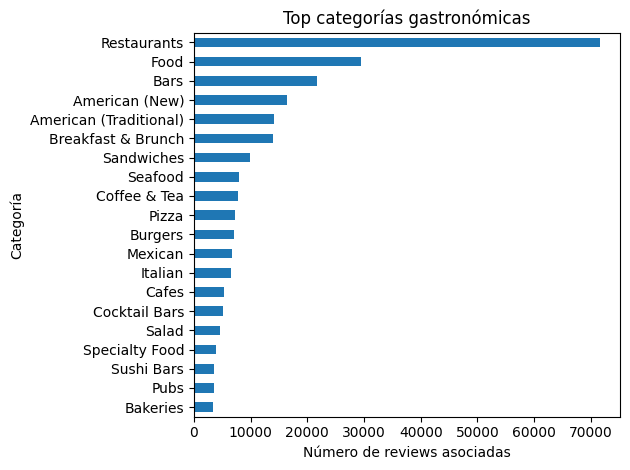

In [8]:
# ============================================================
# 08. EDA inicial para detección de platos
# ============================================================

print("Número de reviews:", len(df))
print("Número de negocios únicos:", df["business_id"].nunique())
print("Número de ciudades únicas:", df["city"].nunique())

print("\nLongitud de textos:")
display(df["text_length_chars"].describe())

print("\nTop ciudades:")
display(df["city"].value_counts().head(20))

print("\nTop estados:")
display(df["state"].value_counts().head(20))

# Categorías
category_counter = Counter()

for tags in df["food_category_tags"]:
    for tag in safe_list(tags):
        category_counter[tag] += 1

category_df = pd.DataFrame(
    category_counter.most_common(50),
    columns=["category", "count"]
)

display(category_df.head(30))

plt.figure(figsize=(10, 5))
category_df.head(20).sort_values("count").plot(
    x="category",
    y="count",
    kind="barh",
    legend=False
)
plt.title("Top categorías gastronómicas")
plt.xlabel("Número de reviews asociadas")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

## Enfoque inicial de detección débil

Como el corpus no contiene anotaciones BIO de platos, se construirá una primera detección débil basada en:

1. un diccionario inicial de términos gastronómicos;
2. patrones frecuentes de reseñas;
3. extracción de n-gramas alrededor de verbos como `ordered`, `had`, `tried`, `loved`;
4. revisión posterior de falsos positivos.

Esta detección no será todavía el modelo final, sino una herramienta para construir datos de entrenamiento y entender el dominio.

In [11]:
# ============================================================
# 09. Diccionario inicial de términos gastronómicos en inglés
# ============================================================

FOOD_TERMS_EN = [
    # Generic
    "food", "dish", "dishes", "meal", "menu", "appetizer", "appetizers",
    "starter", "starters", "entree", "entrees", "main course", "dessert", "desserts",

    # American / common
    "burger", "burgers", "cheeseburger", "cheeseburgers",
    "pizza", "pizzas", "sandwich", "sandwiches",
    "fries", "french fries", "home fries",
    "wings", "chicken wings", "fried chicken",
    "ribs", "ribeye", "steak", "steaks", "brisket", "pulled pork",
    "bbq", "barbecue", "hot dog", "hot dogs", "sonoran dog",

    # Italian
    "pasta", "penne", "spaghetti", "lasagna", "lasagne",
    "gnocchi", "gnocchi with marinara", "marinara",
    "eggplant", "baked eggplant", "veal milanese",
    "ravioli", "risotto", "fettuccine", "alfredo",

    # Mexican / Latin
    "taco", "tacos", "burrito", "burritos",
    "quesadilla", "quesadillas", "enchilada", "enchiladas",
    "tamale", "tamales", "salsa", "guacamole", "nachos",
    "fajitas", "chimichanga",

    # Asian
    "sushi", "sashimi", "ramen", "noodles", "pho",
    "curry", "lamb curry", "korma", "naan",
    "dumpling", "dumplings", "tempura", "edamame",
    "pad thai", "fried rice", "lo mein", "spring rolls",
    "salmon", "tuna", "tuna tacos",

    # Breakfast / brunch
    "breakfast", "brunch", "waffle", "waffles",
    "pancake", "pancakes", "french toast",
    "omelet", "omelette", "eggs benedict",
    "bacon", "eggs", "hash browns",

    # Seafood
    "seafood", "crab", "crab legs", "crab cake", "crab cakes",
    "oyster", "oysters", "calamari", "shrimp", "lobster",
    "mussels", "clams", "fish and chips",

    # Soups / salads / sides
    "salad", "salads", "soup", "soups", "hummus",
    "mac and cheese", "mashed potatoes", "coleslaw",

    # Desserts / bakery
    "cake", "cakes", "pie", "pumpkin pie", "cheesecake",
    "ice cream", "custard", "frozen custard",
    "donut", "donuts", "pastry", "pastries", "croissant",

    # Drinks that may appear in food reviews
    "latte", "coffee", "tea", "smoothie", "milkshake",
]

# Normalizar y ordenar por longitud descendente para detectar primero expresiones largas.
FOOD_TERMS_EN = sorted(
    set(term.lower().strip() for term in FOOD_TERMS_EN if term.strip()),
    key=len,
    reverse=True
)

print("Número de términos iniciales:", len(FOOD_TERMS_EN))
print(FOOD_TERMS_EN[:40])

Número de términos iniciales: 141
['gnocchi with marinara', 'mashed potatoes', 'fish and chips', 'baked eggplant', 'frozen custard', 'mac and cheese', 'veal milanese', 'cheeseburgers', 'fried chicken', 'chicken wings', 'eggs benedict', 'spring rolls', 'french fries', 'cheeseburger', 'french toast', 'chimichanga', 'quesadillas', 'hash browns', 'sonoran dog', 'pulled pork', 'main course', 'pumpkin pie', 'quesadilla', 'fettuccine', 'appetizers', 'crab cakes', 'tuna tacos', 'enchiladas', 'sandwiches', 'fried rice', 'lamb curry', 'cheesecake', 'home fries', 'guacamole', 'ice cream', 'enchilada', 'appetizer', 'croissant', 'crab cake', 'spaghetti']


In [12]:
# ============================================================
# 10. Detección por diccionario
# ============================================================

food_terms_pattern = re.compile(
    r"\b(" + "|".join(re.escape(term) for term in FOOD_TERMS_EN) + r")\b",
    flags=re.IGNORECASE
)

def find_dictionary_food_terms(text: str) -> list[str]:
    if not isinstance(text, str):
        return []

    matches = food_terms_pattern.findall(text)
    normalized_matches = sorted(set(match.lower().strip() for match in matches))

    return normalized_matches


df["dict_food_terms"] = df["text_clean"].apply(find_dictionary_food_terms)
df["dict_food_term_count"] = df["dict_food_terms"].apply(len)
df["has_dict_food_term"] = df["dict_food_term_count"] > 0

print("Reviews con al menos un término del diccionario:")
print(df["has_dict_food_term"].mean().round(4), "->", df["has_dict_food_term"].sum(), "reviews")

print("\nDistribución de número de términos detectados:")
display(df["dict_food_term_count"].describe())

display(
    df[df["has_dict_food_term"]]
    .sort_values("dict_food_term_count", ascending=False)
    [
        [
            "sentiment_label",
            "rating_value",
            "dict_food_term_count",
            "dict_food_terms",
            "text_clean"
        ]
    ]
    .head(10)
)

Reviews con al menos un término del diccionario:
0.8572 -> 67953 reviews

Distribución de número de términos detectados:


count    79270.000000
mean         2.308768
std          2.016229
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         22.000000
Name: dict_food_term_count, dtype: float64

,sentiment_label,rating_value,dict_food_term_count,dict_food_terms,text_clean
61855,positive,5.0,22,"[appetizers, bacon, bbq, brunch, cake, crab, crab cake, dishes, eggplant, eggs, entrees, food, fries, menu, oysters, pasta, pizza, pizzas, sandwich, sandwiches, seafood, shrimp]","I have been patronizing Katie's since early 1999, back in my days of being employed by the City of NOLA. It is one of my absolute favorite restaurants in the city and has never left me anything but completely satiated after every visit. It is also one of my go to spots for out of town guests who..."
37574,positive,5.0,21,"[brisket, chicken wings, dessert, dishes, entrees, food, fried chicken, fried rice, ice cream, menu, noodles, pho, shrimp, smoothie, soup, soups, starters, tacos, tea, waffle, waffles]",One of my favorites in town! I've tried almost everything on the menu... and love it alllllll! These are my favorite dishes: *Starters Shrimp and Pork Rolls Pork Belly Tacos STICKY CHICKEN WINGS *Soups Wonton Soup Pho Brisket add Meatballs Tofu & Tomato Pho *Entrees Lemongrass Chicken and Fried ...
45901,positive,5.0,21,"[appetizer, cake, calamari, dessert, dishes, eggplant, entree, food, ice cream, main course, mashed potatoes, meal, menu, mussels, pastry, salad, salmon, seafood, soup, soups, steak]","This review is for their restaurant week selection. WOW! So good. 4 course meal (plus bread) for $35 each, plus tax and tip. If I had to do it again, I'd choose the Tarte de Legumes, the Saumon, and the Tart Tatin. Also, good-sized portions on everything! Not tiny little fancy portions. FOOD: --..."
58804,positive,5.0,21,"[appetizer, appetizers, cake, dessert, dish, donut, entree, entrees, food, gnocchi, ice cream, lobster, meal, menu, pie, salad, salmon, seafood, soup, steaks, tuna]",RW review: I had the BEST time last night at Square 1682 for RW festivities! We had a reservation for 7:30pm for party of 6. My husband and I arrived a few minutes early and were greeted by a sleek hostess immediately and even took our coats. We checked out the bar area downstairs and ordered an...
43719,positive,4.0,20,"[appetizer, appetizers, crab, dessert, dumpling, dumplings, entrees, food, ice cream, lobster, main course, menu, salad, salmon, sashimi, shrimp, sushi, tea, tempura, tuna]","If you're looking for an affordable and filling sushi spot, Megu is a Japanese restaurant located in Cherry Hill, New Jersey in the Village Walk Shopping Center. Also, it is BYOB and does not charge a corking fee. As you walk through the doors of Megu, you're immediately greeted by a server or o..."
22784,positive,4.0,19,"[bacon, breakfast, burgers, coffee, coleslaw, entrees, food, french toast, mashed potatoes, menu, omelet, omelette, pancake, pancakes, pie, salad, sandwich, sandwiches, soup]","Food is consistently good, reasonably priced and all entrees offered all day. Very friendly waitresses. NOW open for breakfast and lunch (6am - 3 pm). NO longer open until 8:00 p.m. All menu items offered open till close. Perfect when I want lunch and hubby wants breakfast. We've been coming her..."
8209,neutral,3.0,18,"[bacon, brisket, cake, coffee, curry, dessert, dish, dishes, eggplant, food, ice cream, meal, menu, pasta, risotto, salad, soup, tempura]","My husband, daughter, and I dined at Sbraga tonight, excited to try Top Chef winner Kevin Sbraga's fare. We're all educated foodies and 2 of 3 of us like aggressively seasoned food. From our reservation through receiving our check, the service was outstanding, attentive without being overbearing..."
53591,positive,4.0,18,"[bacon, bbq, brisket, brunch, burger, cheeseburger, chicken wings, dish, dishes, food, menu, nachos, pulled pork, salad, salsa, sandwich, soup, wings]","Khyber Pass Pub is located in a historic city, in a historic building, with a historic bar that came from the Centennial World's Fair if 1876. Khyber Pass itself, has only been open since 1970, making it a baby in comparison. Still, the place is dark (even in the daytime),

,term,review_count
0,food,36156
1,menu,10356
2,meal,6718
3,salad,5774
4,pizza,4848
5,coffee,4399
6,sandwich,4359
7,breakfast,4340
8,fries,4238
9,shrimp,4085


<Figure size 1000x600 with 0 Axes>

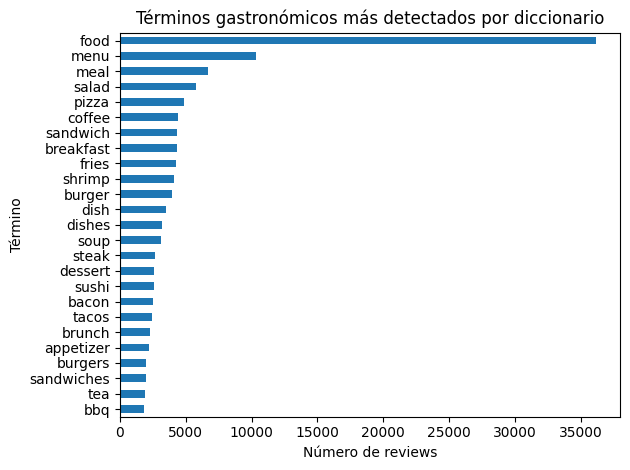

In [13]:
# ============================================================
# 11. Frecuencia de términos detectados
# ============================================================

term_counter = Counter()

for terms in df["dict_food_terms"]:
    for term in terms:
        term_counter[term] += 1

term_freq_df = pd.DataFrame(
    term_counter.most_common(),
    columns=["term", "review_count"]
)

display(term_freq_df.head(50))

plt.figure(figsize=(10, 6))
term_freq_df.head(25).sort_values("review_count").plot(
    x="term",
    y="review_count",
    kind="barh",
    legend=False
)
plt.title("Términos gastronómicos más detectados por diccionario")
plt.xlabel("Número de reviews")
plt.ylabel("Término")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 12. Patrones lingüísticos de consumo
# ============================================================

CONSUMPTION_PATTERNS = [
    r"\bi had (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bwe had (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bi ordered (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bwe ordered (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bi tried (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bwe tried (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bi got (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bwe got (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bi loved (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bwe loved (?:the|a|an|some)?\s+([^.!?,;]{2,80})",
    r"\bmy favorite (?:was|is)\s+([^.!?,;]{2,80})",
    r"\bour favorite (?:was|is)\s+([^.!?,;]{2,80})",
    r"\bthe ([^.!?,;]{2,80}) was (?:amazing|delicious|great|good|excellent|fantastic|bad|awful|bland|cold|dry|overcooked)",
]

compiled_patterns = [re.compile(pattern, flags=re.IGNORECASE) for pattern in CONSUMPTION_PATTERNS]

STOP_TAIL_WORDS = [
    "and", "but", "because", "with", "for", "when", "while", "which",
    "that", "this", "it", "they", "we", "i", "my", "our"
]

def clean_candidate_phrase(phrase: str) -> str:
    if not isinstance(phrase, str):
        return ""

    phrase = phrase.lower().strip()
    phrase = re.sub(r"\s+", " ", phrase)
    phrase = phrase.strip(" -_:;,.!?()[]{}\"'")

    # Cortar en conectores si aparecen demasiado pronto
    for sep in [" and ", " but ", " because ", " which ", " that "]:
        if sep in phrase:
            phrase = phrase.split(sep)[0].strip()

    # Quitar determinantes iniciales repetidos
    phrase = re.sub(r"^(the|a|an|some|our|my)\s+", "", phrase)

    # Quitar cola rara
    words = phrase.split()
    while words and words[-1] in STOP_TAIL_WORDS:
        words = words[:-1]

    phrase = " ".join(words).strip()

    return phrase


def extract_pattern_candidates(text: str) -> list[str]:
    if not isinstance(text, str):
        return []

    candidates = []

    for pattern in compiled_patterns:
        for match in pattern.findall(text):
            candidate = clean_candidate_phrase(match)
            if 2 <= len(candidate) <= 80:
                candidates.append(candidate)

    return sorted(set(candidates))


df["pattern_candidates"] = df["text_clean"].apply(extract_pattern_candidates)
df["pattern_candidate_count"] = df["pattern_candidates"].apply(len)
df["has_pattern_candidate"] = df["pattern_candidate_count"] > 0

print("Reviews con candidatos por patrón:")
print(df["has_pattern_candidate"].mean().round(4), "->", df["has_pattern_candidate"].sum(), "reviews")

display(
    df[df["has_pattern_candidate"]]
    .sort_values("pattern_candidate_count", ascending=False)
    [
        [
            "sentiment_label",
            "rating_value",
            "pattern_candidate_count",
            "pattern_candidates",
            "text_clean"
        ]
    ]
    .head(10)
)

Reviews con candidatos por patrón:
0.2616 -> 20738 reviews


,sentiment_label,rating_value,pattern_candidate_count,pattern_candidates,text_clean
58804,positive,5.0,9,"[best time last night at square 1682 for rw festivities, bite, fish, pan seared grouper with white sweet potatoes, reservation for 7:30pm for party of 6, service, sweet potatoes, taste of the octopus, tuna tostada]",RW review: I had the BEST time last night at Square 1682 for RW festivities! We had a reservation for 7:30pm for party of 6. My husband and I arrived a few minutes early and were greeted by a sleek hostess immediately and even took our coats. We checked out the bar area downstairs and ordered an...
78871,positive,5.0,7,"[baklava, chocolate stout cake, espresso, gnocchi, grandpa's ex, honeycomb tiles in the bathroom, outsider - it was like a fancy pink lemonade]","I absolutely LOVED this place. Maybe it was because my husband and I have fancy date nights about twice a year, but, seriously, I was so impressed! The decor was simple and rustic. (I loved the honeycomb tiles in the bathroom...clever!) For our drinks, we ordered a Grandpa's Ex and an Outsider. ..."
4352,positive,4.0,7,"[calamari, foie gras soup, meatloaf - it was excellent, pistachio bread putting, salmon, salsa verde, third course i had the meatloaf -]",You would think when you have a prix fixe menu it would make it easier to choose what you want to eat - at Sbraga this is definitely not the case. It is actually quite complex and involves solid negotiating and compromising skills with your fellow table-mates to ensure that you get a bite of eve...
35303,positive,4.0,7,"[8 oz prime filet steak, asiago bread, classic wedge salad, good manhattan, lobster bisque soup, party of eleven people (approx $500, staff]","I really enjoyed Mo's downtown. The staff was excellent, the food was very flavorful, and the atmosphere is elegant and cozy with the fireplace and piano man. The men's bathrooms even have cologne and the women's restroom was stocked with a basket of hygiene products! They give complimentary bre..."
69365,positive,5.0,7,"[3 pieces of chicken, bread basket, eggs, mashed potatoes, orange marmalade, pimento, sautéed greens]","My husband and I went last night and LOVED it. My husband is still carrying on about it as of this morning. Mind you, it's day 12 of their opening. Out of respect, you aren't even supposed to rate a restaurant until they've been open a month. It's just the right thing to do since most are workin..."
45901,positive,5.0,6,"[calamars, lamb (agneau, salmon (""saumon: pistachio, sustainably-harvested calamari stuffed with house-made provençal sausage, tapenade, tart tatin]","This review is for their restaurant week selection. WOW! So good. 4 course meal (plus bread) for $35 each, plus tax and tip. If I had to do it again, I'd choose the Tarte de Legumes, the Saumon, and the Tart Tatin. Also, good-sized portions on everything! Not tiny little fancy portions. FOOD: --..."
71568,positive,5.0,6,"[enchilada mixed meat, end of the meal, food, margaritas, server named fernando he was excellent, service to the food]","I was visiting tampa and always go to the normal chain restaurants when out there. Decided to try something new and I am glad I did. Coming for NYC where all we eat is Mexican,Chinese and BBQ I didn't have my expectation too high. However Besito was AMAZING! Everything from the service to the fo..."
4288,negative,2.0,6,"[appearance of the bar, child with us who ordered silver dollar pancakes, decor of this place enough, different shades of woods used paired with shades of blues, huevous ranchos, oversized comfortable furniture]",I wanted to love this place! From the moment I walked in I was impressed. The decor is so comforting. I loved the oversized comfortable furniture. It's a combination of industrial and a beach feel. I loved the appearance of the bar and all of the decorative touches down to the painting of the re...
71143,positive,4.0,6,"[chocolate raspberry cake, poached filet of salmon, really nice first time experie

In [15]:
# ============================================================
# 13. Frecuencia de candidatos extraídos por patrón
# ============================================================

pattern_counter = Counter()

for candidates in df["pattern_candidates"]:
    for candidate in candidates:
        pattern_counter[candidate] += 1

pattern_freq_df = pd.DataFrame(
    pattern_counter.most_common(200),
    columns=["candidate", "count"]
)

display(pattern_freq_df.head(50))

# Candidatos de una sola aparición también son interesantes, pero más ruidosos.
print("Total candidatos únicos por patrón:", len(pattern_freq_df))

,candidate,count
0,food,1781
1,service,959
2,shrimp,144
3,chicken,131
4,burger,128
5,pizza,122
6,salad,97
7,atmosphere,97
8,coffee,79
9,beer,71


Total candidatos únicos por patrón: 200


In [16]:
# ============================================================
# 14. Heurística inicial de plausibilidad de candidatos
# ============================================================

BAD_CANDIDATE_PHRASES = {
    "food",
    "service",
    "place",
    "restaurant",
    "experience",
    "time",
    "menu",
    "server",
    "waiter",
    "waitress",
    "staff",
    "atmosphere",
    "ambiance",
    "price",
    "prices",
    "location",
    "table",
    "bar",
    "drink",
    "drinks",
    "water",
}

BAD_START_WORDS = {
    "very", "really", "too", "so", "just", "not", "no",
    "good", "great", "bad", "nice", "friendly", "slow"
}

def is_plausible_dish_candidate(candidate: str) -> bool:
    if not isinstance(candidate, str):
        return False

    candidate = candidate.lower().strip()

    if not candidate:
        return False

    if candidate in BAD_CANDIDATE_PHRASES:
        return False

    words = candidate.split()

    if len(words) > 6:
        return False

    if words[0] in BAD_START_WORDS:
        return False

    # Debe contener alguna letra
    if not re.search(r"[a-z]", candidate):
        return False

    # Evitar frases demasiado genéricas
    if len(candidate) < 3:
        return False

    return True


df["plausible_pattern_candidates"] = df["pattern_candidates"].apply(
    lambda candidates: [c for c in candidates if is_plausible_dish_candidate(c)]
)

df["plausible_pattern_candidate_count"] = df["plausible_pattern_candidates"].apply(len)

print("Reviews con candidatos plausibles por patrón:")
print((df["plausible_pattern_candidate_count"] > 0).mean().round(4))
print((df["plausible_pattern_candidate_count"] > 0).sum())

display(
    df[df["plausible_pattern_candidate_count"] > 0]
    .sort_values("plausible_pattern_candidate_count", ascending=False)
    [
        [
            "sentiment_label",
            "rating_value",
            "plausible_pattern_candidate_count",
            "plausible_pattern_candidates",
            "text_clean"
        ]
    ]
    .head(10)
)

Reviews con candidatos plausibles por patrón:
0.2112
16743


,sentiment_label,rating_value,plausible_pattern_candidate_count,plausible_pattern_candidates,text_clean
69365,positive,5.0,7,"[3 pieces of chicken, bread basket, eggs, mashed potatoes, orange marmalade, pimento, sautéed greens]","My husband and I went last night and LOVED it. My husband is still carrying on about it as of this morning. Mind you, it's day 12 of their opening. Out of respect, you aren't even supposed to rate a restaurant until they've been open a month. It's just the right thing to do since most are workin..."
4352,positive,4.0,6,"[calamari, foie gras soup, meatloaf - it was excellent, pistachio bread putting, salmon, salsa verde]",You would think when you have a prix fixe menu it would make it easier to choose what you want to eat - at Sbraga this is definitely not the case. It is actually quite complex and involves solid negotiating and compromising skills with your fellow table-mates to ensure that you get a bite of eve...
61186,positive,5.0,6,"[cornbread (in a skillet, hot chicken, mac, pimento cheese, rib, triple chocolate cake]","Unbeknownst to me, the only menu that was available on Sunday 10/2 was the ""Sunday Supper"" tasting menu. I was disappointed I didn't get to try the brisket and wagyu burger sliders, but it was nice to have dishes constantly brought to me. The menu included (for $30): seasonal salad (I didn't ask..."
78871,positive,5.0,6,"[baklava, chocolate stout cake, espresso, gnocchi, grandpa's ex, honeycomb tiles in the bathroom]","I absolutely LOVED this place. Maybe it was because my husband and I have fancy date nights about twice a year, but, seriously, I was so impressed! The decor was simple and rustic. (I loved the honeycomb tiles in the bathroom...clever!) For our drinks, we ordered a Grandpa's Ex and an Outsider. ..."
58254,positive,5.0,5,"[first time i went there, food then, last time, soft flour tacos dinner, superior oreo brownie]","My first time going here was almost a year ago and I loved the food then. Today I took my fiancé here and it was his first time here. I got the soft flour tacos dinner, ground beef. It was better than I imagined. When it comes to Mexican restaurants, I start with tacos the first few times I go. ..."
14388,positive,4.0,5,"[clam chowder, crab, crab sandwich, pitcher of firestone, view]","We made our way all the way to the end of the pier and added our name to the wait list. After a 45 minute wait, we finally got to our table outside. The view was amazing and although it was windy and a bit cold, the heaters above our table helped keep us comfortable. The Santa Barbara Shrimp Coc..."
58804,positive,5.0,5,"[bite, fish, sweet potatoes, taste of the octopus, tuna tostada]",RW review: I had the BEST time last night at Square 1682 for RW festivities! We had a reservation for 7:30pm for party of 6. My husband and I arrived a few minutes early and were greeted by a sleek hostess immediately and even took our coats. We checked out the bar area downstairs and ordered an...
51606,neutral,3.0,5,"[appetizer, dressing, royal grill with stutz salad, scoop of after dinner mint, symphony platter to start]","I've been back here 3 times since my horrible experience below. Luckily, I didn't see the waiter in question. I hope he no longer works there! I was brought in the door by the Elite event a few months ago. It is a great space for a party and I really liked the fudge and the boozy ice cream drink..."
4191,neutral,3.0,5,"[miso soup, rock shrimp tempura, spicy tuna crunch, tuna-tuna roll, waitstaff]","The miso soup was great, very flavorful. The portions were very big we ordered several rolls and definitely had leftovers. The tuna-tuna roll was good, the mango was a great flavor combined with the tuna and ponzu sauce. The spicy tuna crunch was great too. The waitstaff was fantastic, couldn't ..."
53879,positive,5.0,5,"[b&m burger for my meal, carpaccio, delicious meal here, fantastic meal, salad]",My mom and I had a delicious meal here! We are from New Jersey and wanted

In [17]:
# ============================================================
# 15. Construir menciones candidatas débiles
# ============================================================

def build_weak_candidates(row):
    candidates = []

    for term in row["dict_food_terms"]:
        candidates.append({
            "candidate_text": term,
            "candidate_source": "dictionary",
            "confidence_hint": 0.70,
        })

    for candidate in row["plausible_pattern_candidates"]:
        candidates.append({
            "candidate_text": candidate,
            "candidate_source": "pattern",
            "confidence_hint": 0.55,
        })

    # Agrupar por texto, manteniendo fuentes
    grouped = {}

    for item in candidates:
        key = item["candidate_text"].lower().strip()

        if key not in grouped:
            grouped[key] = {
                "candidate_text": key,
                "candidate_sources": set(),
                "confidence_hint": 0.0,
            }

        grouped[key]["candidate_sources"].add(item["candidate_source"])
        grouped[key]["confidence_hint"] = max(
            grouped[key]["confidence_hint"],
            item["confidence_hint"]
        )

    final_candidates = []

    for item in grouped.values():
        sources = sorted(item["candidate_sources"])

        # Si aparece por diccionario y patrón, sube confianza
        if len(sources) > 1:
            confidence = min(0.95, item["confidence_hint"] + 0.20)
        else:
            confidence = item["confidence_hint"]

        final_candidates.append({
            "candidate_text": item["candidate_text"],
            "candidate_sources": sources,
            "weak_confidence": round(confidence, 3),
        })

    final_candidates = sorted(
        final_candidates,
        key=lambda x: (-x["weak_confidence"], x["candidate_text"])
    )

    return final_candidates


df["weak_dish_candidates"] = df.apply(build_weak_candidates, axis=1)
df["weak_dish_candidate_count"] = df["weak_dish_candidates"].apply(len)
df["has_weak_dish_candidate"] = df["weak_dish_candidate_count"] > 0

print("Reviews con al menos un candidato débil:")
print(df["has_weak_dish_candidate"].mean().round(4), "->", df["has_weak_dish_candidate"].sum())

display(
    df[df["has_weak_dish_candidate"]]
    .sort_values("weak_dish_candidate_count", ascending=False)
    [
        [
            "sentiment_label",
            "rating_value",
            "weak_dish_candidate_count",
            "weak_dish_candidates",
            "text_clean"
        ]
    ]
    .head(10)
)

Reviews con al menos un candidato débil:
0.8698 -> 68952


,sentiment_label,rating_value,weak_dish_candidate_count,weak_dish_candidates,text_clean
45901,positive,5.0,26,"[{'candidate_text': 'appetizer', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'cake', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'calamari', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': ...","This review is for their restaurant week selection. WOW! So good. 4 course meal (plus bread) for $35 each, plus tax and tip. If I had to do it again, I'd choose the Tarte de Legumes, the Saumon, and the Tart Tatin. Also, good-sized portions on everything! Not tiny little fancy portions. FOOD: --..."
58804,positive,5.0,26,"[{'candidate_text': 'appetizer', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'appetizers', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'cake', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text'...",RW review: I had the BEST time last night at Square 1682 for RW festivities! We had a reservation for 7:30pm for party of 6. My husband and I arrived a few minutes early and were greeted by a sleek hostess immediately and even took our coats. We checked out the bar area downstairs and ordered an...
37574,positive,5.0,22,"[{'candidate_text': 'brisket', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'chicken wings', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'dessert', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_t...",One of my favorites in town! I've tried almost everything on the menu... and love it alllllll! These are my favorite dishes: *Starters Shrimp and Pork Rolls Pork Belly Tacos STICKY CHICKEN WINGS *Soups Wonton Soup Pho Brisket add Meatballs Tofu & Tomato Pho *Entrees Lemongrass Chicken and Fried ...
61855,positive,5.0,22,"[{'candidate_text': 'appetizers', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'bacon', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'bbq', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'br...","I have been patronizing Katie's since early 1999, back in my days of being employed by the City of NOLA. It is one of my absolute favorite restaurants in the city and has never left me anything but completely satiated after every visit. It is also one of my go to spots for out of town guests who..."
8209,neutral,3.0,20,"[{'candidate_text': 'bacon', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'brisket', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'cake', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'coff...","My husband, daughter, and I dined at Sbraga tonight, excited to try Top Chef winner Kevin Sbraga's fare. We're all educated foodies and 2 of 3 of us like aggressively seasoned food. From our reservation through receiving our check, the service was outstanding, attentive without being overbearing..."
57874,positive,5.0,20,"[{'candidate_text': 'appetizer', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'cake', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'clams', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'cr...","This review is based on two visits and a total of four meals between three people. Also, my visit was prompted by a few unsolicited praises of this restaurant as one of their favorites. I've been to better sushi restaurants. I've been to better Japanese steak houses. I've been to better Benihana..."
43719,positive,4.0,20,"[{'candidate_text': 'appetizer', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'appetizers', 'candidate_

In [18]:
# ============================================================
# 16. Crear tabla plana de candidatos a plato
# ============================================================

candidate_rows = []

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Construyendo tabla de candidatos"):
    for candidate in row.weak_dish_candidates:
        candidate_rows.append({
            "corpus_document_id": row.corpus_document_id,
            "review_id": row.review_id,
            "business_id": row.business_id,
            "business_name": row.business_name,
            "city": row.city,
            "state": row.state,
            "split": row.split,
            "rating_value": row.rating_value,
            "sentiment_label": row.sentiment_label,
            "candidate_text": candidate["candidate_text"],
            "candidate_sources": candidate["candidate_sources"],
            "weak_confidence": candidate["weak_confidence"],
            "text_clean": row.text_clean,
        })

candidates_df = pd.DataFrame(candidate_rows)

print("Total menciones candidatas:", len(candidates_df))
print("Reviews con candidatos:", candidates_df["review_id"].nunique() if len(candidates_df) else 0)
print("Candidatos únicos:", candidates_df["candidate_text"].nunique() if len(candidates_df) else 0)

display(candidates_df.head(10))

Construyendo tabla de candidatos:   0%|          | 0/79270 [00:00<?, ?it/s]

Total menciones candidatas: 202202
Reviews con candidatos: 68952
Candidatos únicos: 14243


,corpus_document_id,review_id,business_id,business_name,city,state,split,rating_value,sentiment_label,candidate_text,candidate_sources,weak_confidence,text_clean
0,yelp_2fbfd094613536a7b8c9231b,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,Turning Point of North Wales,North Wales,PA,train,3.0,neutral,food,[dictionary],0.7,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is good, but it takes a very long time to come out. The..."
1,yelp_94c5a64cecd4448d105e5c8a,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,Kettle Restaurant,Tucson,AZ,train,3.0,neutral,breakfast,[dictionary],0.7,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ..."
2,yelp_94c5a64cecd4448d105e5c8a,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,Kettle Restaurant,Tucson,AZ,train,3.0,neutral,meal,[dictionary],0.7,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ..."
3,yelp_94c5a64cecd4448d105e5c8a,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,Kettle Restaurant,Tucson,AZ,train,3.0,neutral,menu,[dictionary],0.7,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ..."
4,yelp_94c5a64cecd4448d105e5c8a,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,Kettle Restaurant,Tucson,AZ,train,3.0,neutral,tamale,[dictionary],0.7,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ..."
5,yelp_69e10d25d69774ab39af6571,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,train,5.0,positive,lamb curry,"[dictionary, pattern]",0.9,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!"
6,yelp_69e10d25d69774ab39af6571,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,train,5.0,positive,korma,[dictionary],0.7,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!"
7,yelp_69e10d25d69774ab39af6571,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,train,5.0,positive,naan,[dictionary],0.7,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!"
8,yelp_95095495afc3a77ce68723a2,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,Melt,New Orleans,LA,train,4.0,positive,menu,[dictionary],0.7,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwi

,candidate_text,mention_count,review_count,avg_weak_confidence
5323,food,36156,36156,0.700000
8172,menu,10356,10356,0.700000
8032,meal,6718,6718,0.701131
10789,salad,5774,5774,0.703360
9584,pizza,4848,4848,0.705033
...,...,...,...,...
6545,hash browns,279,279,0.700000
6003,gnocchi,277,277,0.706498
12018,spaghetti,274,274,0.703650
3056,chicken wings,265,265,0.704528


<Figure size 1000x600 with 0 Axes>

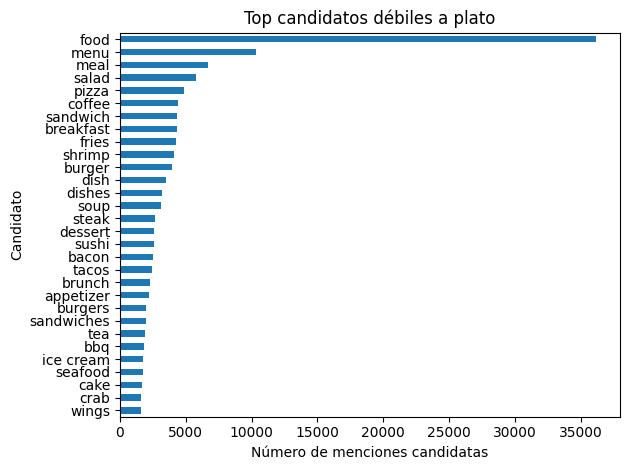

In [19]:
# ============================================================
# 17. Top candidatos débiles
# ============================================================

candidate_freq_df = (
    candidates_df
    .groupby("candidate_text")
    .agg(
        mention_count=("candidate_text", "size"),
        review_count=("review_id", "nunique"),
        avg_weak_confidence=("weak_confidence", "mean"),
    )
    .reset_index()
    .sort_values(["mention_count", "avg_weak_confidence"], ascending=[False, False])
)

display(candidate_freq_df.head(100))

plt.figure(figsize=(10, 6))
candidate_freq_df.head(30).sort_values("mention_count").plot(
    x="candidate_text",
    y="mention_count",
    kind="barh",
    legend=False
)
plt.title("Top candidatos débiles a plato")
plt.xlabel("Número de menciones candidatas")
plt.ylabel("Candidato")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 18. Crear muestra para revisión manual
# ============================================================

# Queremos ejemplos ricos en candidatos, equilibrados por sentimiento.
review_pool = df[df["has_weak_dish_candidate"]].copy()

manual_review_samples = []

for label in ["negative", "neutral", "positive"]:
    subset = review_pool[review_pool["sentiment_label"] == label].copy()

    subset = subset.sort_values(
        ["weak_dish_candidate_count", "dict_food_term_count", "pattern_candidate_count"],
        ascending=False
    )

    manual_review_samples.append(subset.head(50))

manual_review_df = pd.concat(manual_review_samples, ignore_index=True)

manual_review_df = manual_review_df[
    [
        "corpus_document_id",
        "review_id",
        "business_id",
        "business_name",
        "city",
        "state",
        "split",
        "rating_value",
        "sentiment_label",
        "weak_dish_candidates",
        "text_clean",
    ]
].copy()

print("Muestra para revisión manual:", len(manual_review_df))
display(manual_review_df.head(10))

Muestra para revisión manual: 150


,corpus_document_id,review_id,business_id,business_name,city,state,split,rating_value,sentiment_label,weak_dish_candidates,text_clean
0,yelp_3b75e2b178fe2b826c8bc025,2wp62Ta90Kks-c3R7Hg1PA,tYCok-NtWvg8_k7woeB83w,Grand Lux Cafe,Cherry Hill,NJ,validation,2.0,negative,"[{'candidate_text': 'coffee', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'dish', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'dishes', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'edam...","Very disappointed. Decor was okay. Cathedral ceilings and open floor plan. Seemed like an appropriate venue for a wedding reception. Menu had way to many choices. Two pages for just starters. Hard to make up your mind. ""Less is more"". Service was okay. I ordered a seafood salad as my entree, my ..."
1,yelp_a54881de388df6c1412b8c6a,WAG0F2bMt7bySlG-UfICVg,x7_p5O3ChQa7shdHCcLHZQ,Olivier's Creole Restaurant,New Orleans,LA,train,2.0,negative,"[{'candidate_text': 'appetizer', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'breakfast', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'cakes', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text'...","Quick Summary: -Used to love -Terrible experience with service and food last visit and cannot justify going again. Rant: Olivier's used to be my favorite NOLA spot for a special dinner in town. Not as famous as some, but just as delicious. Naturally, I was very eager to take my girlfriend there ..."
2,yelp_deb78caa0e2d0dada5d007e3,SKwGprKz4oD-eSwHGrxsWQ,A2q7d-CBM2-81tVkmS4JMw,The Buffet,Reno,NV,train,2.0,negative,"[{'candidate_text': 'bbq', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'brisket', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'clams', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'crab ...","Over the years, this buffet has sunk in value and food. Weekend price for the Buffet at El Dorado is $22.99. Now for $23 I could get a darn nice meal at many restaurants. But of course not the variety a buffet provides. But you have to be ready to eat $23 worth of food. We had a good server that..."
3,yelp_c906f58fc054fc1c6a560d96,Btlxy41zkC7uudwwUdVEXA,ySXKjndttZjNy3kcqRqG3g,Islamorada Fish Company Restaurant,Tampa,FL,test,2.0,negative,"[{'candidate_text': 'appetizers', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'calamari', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'clams', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text'...","A disappointment to say the least. The food is not bad, just not what I hoped for, which was a great seafood restaurant in Brandon, FL. The wait staff is lacking, like many of the other posts I think they hired absolutely no one with prior wait experience. The service was just ridiculous and not..."
4,yelp_ac90587bcedef1b04b8933cc,Xuk2KDtGFxK6bvgaB9AX6g,0wQCEcpZ57TmTm6EmEDsIw,Hendricks BBQ,St Charles,MO,validation,2.0,negative,"[{'candidate_text': 'appetizer', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'bbq', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'brisket', 'candidate_sources': ['dictionary'], 'weak_confidence': 0.7}, {'candidate_text': 'd...","The excitement of this place has built as we anticipated a nice bbq place in the historic main street area. So, we went about a month after they opened to get some of their brand new restaurant issues out of the way. It was a Sunday afternoon. We were one of 4 tables seated. The inside and the o..."
5,yelp_03953a6b8288ef09bf294995,VqLhu8ZfWW-aaIjkOakFzA,IUgQmteI-mbt_qjL2ZENKA,Epiphany Restaurant,Santa Barbara,CA,train,2.0,negative,"[{'candidate_text': 'cheesecake', 'candidate_source

In [21]:
# ============================================================
# 19. Guardar artefactos
# ============================================================

def make_json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, float) and np.isnan(value):
        return None

    if isinstance(value, set):
        return sorted(list(value))

    return value


def save_jsonl(df_to_save: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as f:
        for record in df_to_save.to_dict(orient="records"):
            clean_record = {
                str(k): make_json_safe(v)
                for k, v in record.items()
            }
            f.write(json.dumps(clean_record, ensure_ascii=False) + "\n")

    print(f"Guardado: {path} ({len(df_to_save):,} registros)")


# Guardar tabla de candidatos
candidates_path = CANDIDATES_DIR / "weak_dish_candidates.jsonl"
candidate_freq_path = CANDIDATES_DIR / "weak_dish_candidate_frequencies.csv"
manual_review_sample_path = SAMPLES_DIR / "dish_detection_manual_review_sample_150.jsonl"

save_jsonl(candidates_df, candidates_path)
candidate_freq_df.to_csv(candidate_freq_path, index=False)
save_jsonl(manual_review_df, manual_review_sample_path)

# Resumen
summary = {
    "notebook": "04_dish_detection_dataset_exploration",
    "source_corpus_path": str(CORPUS_PATH),
    "total_reviews": int(len(df)),
    "unique_businesses": int(df["business_id"].nunique()),
    "reviews_with_dictionary_terms": int(df["has_dict_food_term"].sum()),
    "reviews_with_pattern_candidates": int(df["has_pattern_candidate"].sum()),
    "reviews_with_weak_dish_candidates": int(df["has_weak_dish_candidate"].sum()),
    "total_weak_candidate_mentions": int(len(candidates_df)),
    "unique_weak_candidates": int(candidates_df["candidate_text"].nunique()) if len(candidates_df) else 0,
    "top_weak_candidates": candidate_freq_df.head(30).to_dict(orient="records"),
    "outputs": {
        "weak_dish_candidates": str(candidates_path),
        "weak_dish_candidate_frequencies": str(candidate_freq_path),
        "manual_review_sample": str(manual_review_sample_path),
    }
}

summary_path = ARTIFACTS_DIR / "dish_detection_exploration_summary.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Resumen guardado en:")
print(summary_path)

print(json.dumps(summary, indent=2, ensure_ascii=False)[:3000])

Guardado: /kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration/candidates/weak_dish_candidates.jsonl (202,202 registros)
Guardado: /kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration/samples/dish_detection_manual_review_sample_150.jsonl (150 registros)
Resumen guardado en:
/kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration/artifacts/dish_detection_exploration_summary.json
{
  "notebook": "04_dish_detection_dataset_exploration",
  "source_corpus_path": "/kaggle/input/datasets/ivanarteagacordero/hidden-gems-yelp-nlp/yelp_food_reviews_corpus_sample_100k_lines.jsonl",
  "total_reviews": 79270,
  "unique_businesses": 5141,
  "reviews_with_dictionary_terms": 67953,
  "reviews_with_pattern_candidates": 20738,
  "reviews_with_weak_dish_candidates": 68952,
  "total_weak_candidate_mentions": 202202,
  "unique_weak_candidates": 14243,
  "top_weak_candidates": [
    {
      "candidate_text": "food",
      "mention_count": 36156,
      "review_count": 36156

## Cierre provisional del Notebook 04

En este notebook se ha construido una primera exploración del corpus Yelp para detección de platos.

Se han generado tres artefactos principales:

- `weak_dish_candidates.jsonl`
- `weak_dish_candidate_frequencies.csv`
- `dish_detection_manual_review_sample_150.jsonl`

Estos archivos no representan todavía un dataset NER definitivo, pero sí una primera base para:

- analizar menciones frecuentes de platos;
- detectar falsos positivos;
- construir un diccionario gastronómico más robusto;
- preparar anotación manual;
- diseñar el dataset BIO del futuro modelo NER.

El siguiente paso será revisar los candidatos generados y convertir una muestra controlada en un dataset de anotación para entrenamiento.

## 2. Refinamiento de candidatos débiles v2

La primera exploración ha demostrado que el sistema detecta muchas menciones gastronómicas, pero también introduce ruido.

Aparecen términos muy frecuentes como `food`, `menu`, `meal`, `dish` o `dishes`, que son útiles para saber que una review habla de comida, pero no deberían etiquetarse como platos.

En este bloque se separan tres tipos de términos:

1. **Contexto gastronómico**: términos útiles para filtrar reviews, pero no entidades de plato.
2. **Platos o familias de platos**: `pizza`, `burger`, `sushi`, `tacos`, `salad`.
3. **Variantes concretas de plato**: `crab cakes`, `fried chicken`, `fish and chips`, `pulled pork`.

El objetivo es generar una versión v2 más limpia para la futura construcción del dataset NER.

In [24]:
# ============================================================
# 20. Definir términos genéricos y reglas v2
# ============================================================

# Términos que indican contexto gastronómico, pero NO son platos concretos.
CONTEXT_ONLY_TERMS = {
    "food",
    "menu",
    "meal",
    "dish",
    "dishes",
    "starter",
    "starters",
    "appetizer",
    "appetizers",
    "entree",
    "entrees",
    "main course",
    "dessert",
    "desserts",
    "breakfast",
    "brunch",
    "seafood",
    "bbq",
    "barbecue",
}

# Términos que pueden ser ambiguos: a veces son plato, a veces categoría.
# Los conservamos, pero con menor confianza o como dish_family.
AMBIGUOUS_FOOD_TERMS = {
    "salad",
    "soup",
    "sandwich",
    "coffee",
    "tea",
    "cake",
    "pie",
    "eggs",
    "bacon",
    "pasta",
    "noodles",
    "curry",
}

# Palabras que indican claramente ruido no gastronómico.
NOISE_TERMS = {
    "service",
    "place",
    "restaurant",
    "experience",
    "time",
    "server",
    "waiter",
    "waitress",
    "staff",
    "atmosphere",
    "ambiance",
    "price",
    "prices",
    "location",
    "table",
    "bar",
    "water",
    "bathroom",
    "decor",
    "parking",
    "manager",
    "owner",
}

# Palabras frecuentes que pueden cerrar una frase mal extraída.
BAD_INTERNAL_WORDS = {
    "service",
    "staff",
    "server",
    "waiter",
    "waitress",
    "place",
    "restaurant",
    "experience",
    "atmosphere",
    "ambiance",
    "bathroom",
    "parking",
}

# Cabezas o núcleos de plato frecuentes.
DISH_HEAD_WORDS = {
    "pizza", "burger", "burgers", "cheeseburger", "sandwich", "sandwiches",
    "fries", "wings", "ribs", "steak", "brisket", "pork", "chicken",
    "taco", "tacos", "burrito", "burritos", "quesadilla", "quesadillas",
    "enchilada", "enchiladas", "tamale", "tamales", "nachos",
    "sushi", "sashimi", "ramen", "noodles", "pho", "curry", "korma",
    "naan", "dumpling", "dumplings", "tempura", "edamame",
    "pasta", "penne", "spaghetti", "lasagna", "gnocchi", "ravioli",
    "risotto", "fettuccine", "alfredo", "eggplant",
    "salad", "soup", "hummus",
    "crab", "oyster", "oysters", "shrimp", "lobster", "mussels", "clams",
    "salmon", "tuna", "calamari",
    "waffle", "waffles", "pancake", "pancakes", "omelet", "omelette",
    "bacon", "eggs",
    "cake", "pie", "cheesecake", "ice cream", "custard", "donut", "donuts",
    "latte", "coffee", "tea", "smoothie", "milkshake",
}

# Expresiones multiword que sí son platos/ítems bastante concretos.
STRONG_MULTIWORD_DISHES = {
    "fried chicken",
    "chicken wings",
    "french fries",
    "home fries",
    "pulled pork",
    "crab cakes",
    "crab cake",
    "crab legs",
    "fish and chips",
    "mac and cheese",
    "mashed potatoes",
    "frozen custard",
    "pumpkin pie",
    "french toast",
    "eggs benedict",
    "pad thai",
    "fried rice",
    "lo mein",
    "spring rolls",
    "lamb curry",
    "gnocchi with marinara",
    "veal milanese",
    "baked eggplant",
    "tuna tacos",
    "sonoran dog",
}

print("Context-only terms:", len(CONTEXT_ONLY_TERMS))
print("Ambiguous terms:", len(AMBIGUOUS_FOOD_TERMS))
print("Dish head words:", len(DISH_HEAD_WORDS))
print("Strong multiword dishes:", len(STRONG_MULTIWORD_DISHES))

Context-only terms: 19
Ambiguous terms: 12
Dish head words: 79
Strong multiword dishes: 25


In [25]:
# ============================================================
# 21. Funciones de clasificación de candidatos
# ============================================================

def normalize_candidate_text(candidate: str) -> str:
    if not isinstance(candidate, str):
        return ""

    candidate = candidate.lower().strip()
    candidate = re.sub(r"\s+", " ", candidate)
    candidate = candidate.strip(" -_:;,.!?()[]{}\"'")

    return candidate


def contains_noise(candidate: str) -> bool:
    words = set(candidate.split())
    return len(words & NOISE_TERMS) > 0 or len(words & BAD_INTERNAL_WORDS) > 0


def classify_candidate_granularity(candidate: str) -> str:
    candidate = normalize_candidate_text(candidate)

    if not candidate:
        return "invalid"

    if candidate in CONTEXT_ONLY_TERMS:
        return "context_only"

    if candidate in STRONG_MULTIWORD_DISHES:
        return "dish_variant"

    words = candidate.split()

    if len(words) >= 2:
        if any(word in DISH_HEAD_WORDS for word in words):
            return "dish_variant"

    if candidate in AMBIGUOUS_FOOD_TERMS:
        return "dish_family_ambiguous"

    if candidate in DISH_HEAD_WORDS:
        return "dish_family"

    return "unknown_candidate"


def is_candidate_usable_for_ner(candidate: str) -> bool:
    candidate = normalize_candidate_text(candidate)

    if not candidate:
        return False

    if candidate in CONTEXT_ONLY_TERMS:
        return False

    if contains_noise(candidate):
        return False

    words = candidate.split()

    if len(words) > 6:
        return False

    granularity = classify_candidate_granularity(candidate)

    return granularity in {
        "dish_variant",
        "dish_family",
        "dish_family_ambiguous",
    }


def compute_v2_confidence(candidate: str, candidate_sources, old_confidence: float) -> float:
    candidate = normalize_candidate_text(candidate)
    granularity = classify_candidate_granularity(candidate)

    sources = candidate_sources
    if isinstance(sources, str):
        try:
            sources = json.loads(sources)
        except Exception:
            sources = [sources]

    if not isinstance(sources, list):
        sources = []

    confidence = float(old_confidence)

    if granularity == "dish_variant":
        confidence += 0.15

    elif granularity == "dish_family":
        confidence += 0.05

    elif granularity == "dish_family_ambiguous":
        confidence -= 0.05

    elif granularity == "context_only":
        confidence = 0.0

    elif granularity == "unknown_candidate":
        confidence -= 0.20

    if len(sources) >= 2:
        confidence += 0.10

    if candidate in STRONG_MULTIWORD_DISHES:
        confidence += 0.10

    confidence = max(0.0, min(0.99, confidence))

    return round(confidence, 3)

In [26]:
# ============================================================
# 22. Aplicar refinamiento v2 a candidates_df
# ============================================================

if "candidates_df" not in globals():
    raise RuntimeError(
        "No existe candidates_df en memoria. Ejecuta primero el bloque anterior del Notebook 04."
    )

candidates_v2_df = candidates_df.copy()

candidates_v2_df["candidate_text"] = candidates_v2_df["candidate_text"].apply(normalize_candidate_text)

candidates_v2_df["candidate_granularity"] = candidates_v2_df["candidate_text"].apply(
    classify_candidate_granularity
)

candidates_v2_df["usable_for_ner_weak_label"] = candidates_v2_df["candidate_text"].apply(
    is_candidate_usable_for_ner
)

candidates_v2_df["weak_confidence_v2"] = candidates_v2_df.apply(
    lambda row: compute_v2_confidence(
        row["candidate_text"],
        row["candidate_sources"],
        row["weak_confidence"]
    ),
    axis=1
)

# Filtrado principal
candidates_v2_filtered_df = candidates_v2_df[
    candidates_v2_df["usable_for_ner_weak_label"]
    & (candidates_v2_df["weak_confidence_v2"] >= 0.55)
].copy()

print("Candidatos v1:", len(candidates_df))
print("Candidatos v2 filtrados:", len(candidates_v2_filtered_df))
print("Reducción:", round((1 - len(candidates_v2_filtered_df) / len(candidates_df)) * 100, 2), "%")

print("\nGranularidad v2:")
display(candidates_v2_df["candidate_granularity"].value_counts())

print("\nGranularidad v2 filtrada:")
display(candidates_v2_filtered_df["candidate_granularity"].value_counts())

display(candidates_v2_filtered_df.head(10))

Candidatos v1: 202202
Candidatos v2 filtrados: 100965
Reducción: 50.07 %

Granularidad v2:


candidate_granularity
context_only             80720
dish_family              57367
dish_family_ambiguous    29936
unknown_candidate        20477
dish_variant             13702
Name: count, dtype: int64


Granularidad v2 filtrada:


candidate_granularity
dish_family              57367
dish_family_ambiguous    29936
dish_variant             13662
Name: count, dtype: int64

,corpus_document_id,review_id,business_id,business_name,city,state,split,rating_value,sentiment_label,candidate_text,candidate_sources,weak_confidence,text_clean,candidate_granularity,usable_for_ner_weak_label,weak_confidence_v2
4,yelp_94c5a64cecd4448d105e5c8a,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,Kettle Restaurant,Tucson,AZ,train,3.0,neutral,tamale,[dictionary],0.7,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with ...",dish_family,True,0.75
5,yelp_69e10d25d69774ab39af6571,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,train,5.0,positive,lamb curry,"[dictionary, pattern]",0.9,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",dish_variant,True,0.99
6,yelp_69e10d25d69774ab39af6571,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,train,5.0,positive,korma,[dictionary],0.7,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",dish_family,True,0.75
7,yelp_69e10d25d69774ab39af6571,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,train,5.0,positive,naan,[dictionary],0.7,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",dish_family,True,0.75
9,yelp_95095495afc3a77ce68723a2,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,Melt,New Orleans,LA,train,4.0,positive,salad,[dictionary],0.7,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too m...",dish_family_ambiguous,True,0.65
11,yelp_95095495afc3a77ce68723a2,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,Melt,New Orleans,LA,train,4.0,positive,sandwich,[dictionary],0.7,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too m...",dish_family_ambiguous,True,0.65
12,yelp_95095495afc3a77ce68723a2,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,Melt,New Orleans,LA,train,4.0,positive,sandwiches,[dictionary],0.7,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too m...",dish_family,True,0.75
14,yelp_6ce3d2a264cfcdddc59ac240,_ZeMknuYdlQcUqng_Im3yg,LHSTtnW3YHCeUkRDGyJOyw,Fries Rebellion,Quakertown,PA,train,5.0,positive,wings,[dictionary],0.7,"Amazingly amazing wings and homemade bleu cheese. Had the ribeye: tender, perfectly prepared, delicious. Nice selection of craft beers. Would DEFINITELY recommend checking out this hidden gem.",dish_family,True,0.75
16,yelp_1e7a38ac7da3467ee929e559,pUycOfUwM8vqX7KjRRhUEA,gebiRewfieSdtt17PTW6Zg,Hibachi Steak House & Sushi Bar,Santa Barbara,CA,validation,3.0,neutral,sushi,[dictionary],0.7,Had a party of 6 here for hibachi. Our waitress brought our separate sushi orders on one plate so we couldn't rea

,candidate_text,candidate_granularity,mention_count,review_count,avg_weak_confidence_v2
3769,salad,dish_family_ambiguous,5774,5774,0.655040
3326,pizza,dish_family,4848,4848,0.756040
1404,coffee,dish_family_ambiguous,4399,4399,0.655388
3887,sandwich,dish_family_ambiguous,4359,4359,0.653441
2072,fries,dish_family,4238,4238,0.750566
...,...,...,...,...,...
2606,korma,dish_family,64,64,0.750000
3605,pumpkin pie,dish_variant,32,32,0.951250
3571,pulled pork sandwich,dish_variant,28,28,0.700000
1189,chicken sandwich,dish_variant,26,26,0.700000


<Figure size 1000x600 with 0 Axes>

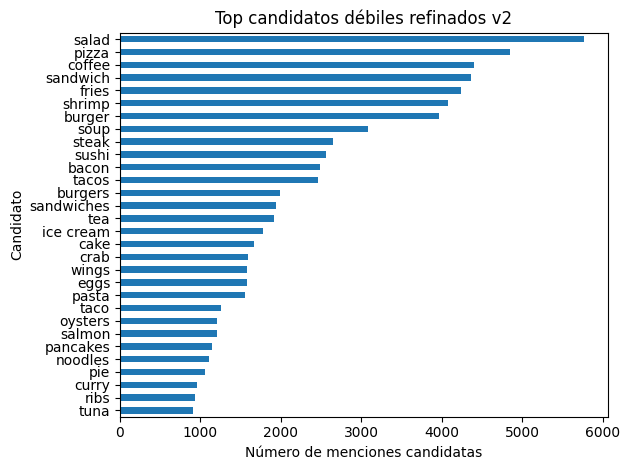

In [27]:
# ============================================================
# 23. Frecuencias refinadas v2
# ============================================================

candidate_freq_v2_df = (
    candidates_v2_filtered_df
    .groupby(["candidate_text", "candidate_granularity"])
    .agg(
        mention_count=("candidate_text", "size"),
        review_count=("review_id", "nunique"),
        avg_weak_confidence_v2=("weak_confidence_v2", "mean"),
    )
    .reset_index()
    .sort_values(["mention_count", "avg_weak_confidence_v2"], ascending=[False, False])
)

display(candidate_freq_v2_df.head(100))

plt.figure(figsize=(10, 6))
candidate_freq_v2_df.head(30).sort_values("mention_count").plot(
    x="candidate_text",
    y="mention_count",
    kind="barh",
    legend=False
)
plt.title("Top candidatos débiles refinados v2")
plt.xlabel("Número de menciones candidatas")
plt.ylabel("Candidato")
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 24. Comparar top v1 vs v2
# ============================================================

top_v1 = candidate_freq_df.head(30)[["candidate_text", "mention_count"]].copy()
top_v1 = top_v1.rename(columns={"mention_count": "mention_count_v1"})

top_v2 = candidate_freq_v2_df.head(30)[["candidate_text", "mention_count"]].copy()
top_v2 = top_v2.rename(columns={"mention_count": "mention_count_v2"})

comparison_top_df = pd.merge(
    top_v1,
    top_v2,
    on="candidate_text",
    how="outer"
).fillna(0)

comparison_top_df["mention_count_v1"] = comparison_top_df["mention_count_v1"].astype(int)
comparison_top_df["mention_count_v2"] = comparison_top_df["mention_count_v2"].astype(int)

display(comparison_top_df.sort_values("mention_count_v2", ascending=False))

,candidate_text,mention_count_v1,mention_count_v2
27,salad,5774,5774
25,pizza,4848,4848
8,coffee,4399,4399
29,sandwich,4359,4359
16,fries,4238,4238
32,shrimp,4085,4085
5,burger,3966,3966
33,soup,3085,3085
34,steak,2648,2648
35,sushi,2567,2567


In [29]:
# ============================================================
# 25. Crear lexicón semilla de platos
# ============================================================

dish_lexicon_seed_df = candidate_freq_v2_df.copy()

dish_lexicon_seed_df["canonical_dish_name"] = dish_lexicon_seed_df["candidate_text"]

dish_lexicon_seed_df["dish_family"] = dish_lexicon_seed_df["candidate_text"].apply(
    lambda x: x.split()[-1] if isinstance(x, str) and len(x.split()) > 1 else x
)

dish_lexicon_seed_df["language"] = "en"
dish_lexicon_seed_df["lexicon_source"] = "weak_detection_v2"
dish_lexicon_seed_df["manual_review_status"] = "pending"
dish_lexicon_seed_df["include_in_ner_dictionary"] = True

# Priorizamos revisión manual: frecuentes + variantes concretas
dish_lexicon_seed_df["manual_review_priority"] = dish_lexicon_seed_df.apply(
    lambda row: (
        3 if row["candidate_granularity"] == "dish_variant" and row["mention_count"] >= 50
        else 2 if row["mention_count"] >= 100
        else 1
    ),
    axis=1
)

display(dish_lexicon_seed_df.head(50))

,candidate_text,candidate_granularity,mention_count,review_count,avg_weak_confidence_v2,canonical_dish_name,dish_family,language,lexicon_source,manual_review_status,include_in_ner_dictionary,manual_review_priority
3769,salad,dish_family_ambiguous,5774,5774,0.655040,salad,salad,en,weak_detection_v2,pending,True,2
3326,pizza,dish_family,4848,4848,0.756040,pizza,pizza,en,weak_detection_v2,pending,True,2
1404,coffee,dish_family_ambiguous,4399,4399,0.655388,coffee,coffee,en,weak_detection_v2,pending,True,2
3887,sandwich,dish_family_ambiguous,4359,4359,0.653441,sandwich,sandwich,en,weak_detection_v2,pending,True,2
2072,fries,dish_family,4238,4238,0.750566,fries,fries,en,weak_detection_v2,pending,True,2
4010,shrimp,dish_family,4085,4085,0.758460,shrimp,shrimp,en,weak_detection_v2,pending,True,2
666,burger,dish_family,3966,3966,0.757746,burger,burger,en,weak_detection_v2,pending,True,2
4262,soup,dish_family_ambiguous,3085,3085,0.653404,soup,soup,en,weak_detection_v2,pending,True,2
4424,steak,dish_family,2648,2648,0.756073,steak,steak,en,weak_detection_v2,pending,True,2
4539,sushi,dish_family,2567,2567,0.754020,sushi,sushi,en,weak_detection_v2,pending,True,2


In [30]:
# ============================================================
# 26. Crear muestra manual v2 para revisión de platos
# ============================================================

# Agrupar candidatos v2 por review
grouped_candidates_v2 = (
    candidates_v2_filtered_df
    .groupby("review_id")
    .apply(
        lambda group: group[
            [
                "candidate_text",
                "candidate_granularity",
                "candidate_sources",
                "weak_confidence_v2"
            ]
        ].to_dict(orient="records")
    )
    .to_dict()
)

df_v2_sample_pool = df[df["review_id"].isin(grouped_candidates_v2.keys())].copy()
df_v2_sample_pool["weak_dish_candidates_v2"] = df_v2_sample_pool["review_id"].map(grouped_candidates_v2)
df_v2_sample_pool["weak_dish_candidate_count_v2"] = df_v2_sample_pool["weak_dish_candidates_v2"].apply(len)

manual_review_samples_v2 = []

for label in ["negative", "neutral", "positive"]:
    subset = df_v2_sample_pool[df_v2_sample_pool["sentiment_label"] == label].copy()

    subset = subset.sort_values(
        ["weak_dish_candidate_count_v2", "text_length_chars"],
        ascending=[False, False]
    )

    manual_review_samples_v2.append(subset.head(50))

manual_review_v2_df = pd.concat(manual_review_samples_v2, ignore_index=True)

manual_review_v2_df = manual_review_v2_df[
    [
        "corpus_document_id",
        "review_id",
        "business_id",
        "business_name",
        "city",
        "state",
        "split",
        "rating_value",
        "sentiment_label",
        "weak_dish_candidates_v2",
        "text_clean",
    ]
].copy()

print("Muestra manual v2:", len(manual_review_v2_df))

display(manual_review_v2_df.head(10))

Muestra manual v2: 150


,corpus_document_id,review_id,business_id,business_name,city,state,split,rating_value,sentiment_label,weak_dish_candidates_v2,text_clean
0,yelp_deb78caa0e2d0dada5d007e3,SKwGprKz4oD-eSwHGrxsWQ,A2q7d-CBM2-81tVkmS4JMw,The Buffet,Reno,NV,train,2.0,negative,"[{'candidate_text': 'brisket', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.75}, {'candidate_text': 'clams', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.75}, {'candidate_text': 'crab ...","Over the years, this buffet has sunk in value and food. Weekend price for the Buffet at El Dorado is $22.99. Now for $23 I could get a darn nice meal at many restaurants. But of course not the variety a buffet provides. But you have to be ready to eat $23 worth of food. We had a good server that..."
1,yelp_27f420da8d25193de755bc85,Mm2FOIieLru-BdZXMgvTrA,PW6C4OMpPQ_Zm7oiwNIVgw,Anjou Restaurant,Philadelphia,PA,train,1.0,negative,"[{'candidate_text': 'cheesecake', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.75}, {'candidate_text': 'gnocchi', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.75}, {'candidate_text': '...","It was a Saturday night and market st in Philly was swarming with people. My friends and I checked 2 restaurants but they both had over an hour long waits. The wait at Anjou? Non existant. That should have been a red flag right there but we were starving and they had couscous on the menu, April'..."
2,yelp_4bce3e424b1f669e4c72c97f,hQZLwzQiuqsjfbq4D_48qQ,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,New Orleans,LA,train,2.0,negative,"[{'candidate_text': 'bacon', 'candidate_granularity': 'dish_family_ambiguous', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.65}, {'candidate_text': 'clams', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.75}, {'candidate_text'...","THE GOOD: great food for a decent price. We got the $65 oyster platter which came with 12 huge and succulent oysters, about a dozen each of clams and mussels, 10-12 tails of jumbo shrimp, about half of a huge king crab, 2 small sauce cups of ceviche, and 3 different sauces including a malt vineg..."
3,yelp_5a54252b167de83da380485f,glEcAUzdCdK68ed_Dd8ugw,Rf7ChSNhY3U3SzBVxpup1w,Billingsgate Fish Co.,Edmonton,AB,train,2.0,negative,"[{'candidate_text': 'crab', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.75}, {'candidate_text': 'french fries', 'candidate_granularity': 'dish_variant', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.95}, {'candidate_text': '...","So Billingsgate used to be a sit down meal experience. It was a place where I could take out of town visitors for some really good, fresh fish. I was a little disappointed to find out that you go up to the till, place your order and pay for your meal BEFORE you sit at your table. So here is anot..."
4,yelp_73cfad4cf5bb0d79d856db05,CHxn1GnUZGMFzyGCJeiFaA,NT5S6JV5wPwKOd3s3Yh1zQ,Burger Up,Nashville,TN,train,1.0,negative,"[{'candidate_text': 'burger', 'candidate_granularity': 'dish_family', 'candidate_sources': ['dictionary', 'pattern'], 'weak_confidence_v2': 0.99}, {'candidate_text': 'bacon', 'candidate_granularity': 'dish_family_ambiguous', 'candidate_sources': ['dictionary'], 'weak_confidence_v2': 0.65}, {'can...","I went to Burger Up last night - I waited 30 minutes for a table and was sat at an extremely uncomfortable hightop table - we asked to move and we were graciously sat elsewhere. However, the tables are so close together that it is awkward. After about ten minutes we were able to order drinks and..."
5,yelp_c6d401f268aabd9f9ef97b22,Sf_BLx6qPzaHut5o2wrkjw,l3pO6YTjFUgVoXgm3gfUag,Ichiban Buffet,Cherry Hill,NJ,test,1.0,negative,"[{'candidate_text': 'chicken wings', 'candidate_granularity': 'dish_variant', 'candidate_sources': ['d

In [31]:
# ============================================================
# 27. Guardar artefactos v2
# ============================================================

candidates_v2_path = CANDIDATES_DIR / "weak_dish_candidates_v2.jsonl"
candidate_freq_v2_path = CANDIDATES_DIR / "weak_dish_candidate_frequencies_v2.csv"
dish_lexicon_seed_path = ARTIFACTS_DIR / "dish_lexicon_seed_v1.csv"
manual_review_v2_path = SAMPLES_DIR / "dish_detection_manual_review_sample_v2_150.jsonl"

save_jsonl(candidates_v2_filtered_df, candidates_v2_path)
candidate_freq_v2_df.to_csv(candidate_freq_v2_path, index=False)
dish_lexicon_seed_df.to_csv(dish_lexicon_seed_path, index=False)
save_jsonl(manual_review_v2_df, manual_review_v2_path)

summary_v2 = {
    "notebook": "04_dish_detection_dataset_exploration",
    "version": "v2_refined_candidates",
    "source_corpus_path": str(CORPUS_PATH),
    "total_reviews": int(len(df)),
    "unique_businesses": int(df["business_id"].nunique()),

    "v1": {
        "total_weak_candidate_mentions": int(len(candidates_df)),
        "unique_weak_candidates": int(candidates_df["candidate_text"].nunique()),
    },

    "v2": {
        "total_weak_candidate_mentions": int(len(candidates_v2_filtered_df)),
        "unique_weak_candidates": int(candidates_v2_filtered_df["candidate_text"].nunique()),
        "reviews_with_weak_candidates": int(candidates_v2_filtered_df["review_id"].nunique()),
        "candidate_granularity_counts": {
            str(k): int(v)
            for k, v in candidates_v2_filtered_df["candidate_granularity"].value_counts().to_dict().items()
        },
        "top_weak_candidates": candidate_freq_v2_df.head(30).to_dict(orient="records"),
    },

    "outputs": {
        "weak_dish_candidates_v2": str(candidates_v2_path),
        "weak_dish_candidate_frequencies_v2": str(candidate_freq_v2_path),
        "dish_lexicon_seed_v1": str(dish_lexicon_seed_path),
        "manual_review_sample_v2": str(manual_review_v2_path),
    }
}

summary_v2_path = ARTIFACTS_DIR / "dish_detection_exploration_summary_v2.json"

with summary_v2_path.open("w", encoding="utf-8") as f:
    json.dump(summary_v2, f, indent=2, ensure_ascii=False)

print("Resumen v2 guardado en:")
print(summary_v2_path)

print(json.dumps(summary_v2, indent=2, ensure_ascii=False)[:3000])

Guardado: /kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration/candidates/weak_dish_candidates_v2.jsonl (100,965 registros)
Guardado: /kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration/samples/dish_detection_manual_review_sample_v2_150.jsonl (150 registros)
Resumen v2 guardado en:
/kaggle/working/hidden_gems_ai/outputs/dish_detection_exploration/artifacts/dish_detection_exploration_summary_v2.json
{
  "notebook": "04_dish_detection_dataset_exploration",
  "version": "v2_refined_candidates",
  "source_corpus_path": "/kaggle/input/datasets/ivanarteagacordero/hidden-gems-yelp-nlp/yelp_food_reviews_corpus_sample_100k_lines.jsonl",
  "total_reviews": 79270,
  "unique_businesses": 5141,
  "v1": {
    "total_weak_candidate_mentions": 202202,
    "unique_weak_candidates": 14243
  },
  "v2": {
    "total_weak_candidate_mentions": 100965,
    "unique_weak_candidates": 5123,
    "reviews_with_weak_candidates": 49189,
    "candidate_granularity_counts": {
      "dish_fa